# R00 - Ansatz Validation and VQE Analysis for the Lattice Schwinger Model

**Author**: oscar-vbl

**Project:** `Lattice-QFT-Quantum-Simulation`  

## Summary
On this notebook, we are going to validate the results obtained with the simulation tools developed in this repository for vacuum preparation in the 1+1D lattice Schwinger model, comparing them with their numerical values. The objective is to study different ansatzes, and check which one suits better for future simulations. The comparison is not restricted to the ground state energy, it also includes state fidelity, optimization time, computational resources and a barren plateaus diagnosis through gradient variance.

Each simulation is performed calling the script SchwingerSimulation.py ideally without a backend, comparing the results with exact diagonalization results to check the metrics of the different aproaches.

For all the metrics analysis, we have performed 15 runs for each individual configuration, from which we have taken the 5 with lower energy, as we are looking for the ground state, as a practical way of avoiding clearly suboptimal variational states in later analysis.

## Theoretical Framework: VQE and Schwinger Model

We are using a VQE (Variational Quantum Eigensolver) to find the ground state of the hamiltonian of the 1+1 dimensional Schwinger model. We have used the Kogut-Sussking formulation with staggered fermions, which allows us to transform the fermionic degrees of freedom to a spin chain of $L$ sites through the Jordan-Wigner transform. We are used the temporal gauge $(A_0=0)$, with the hamiltonian as

$$H = w \sum_{n=1}^{L-1} \left[ \sigma^+_n \sigma^-_{n+1} + \sigma^-_n \sigma^+_{n+1} \right] + \frac{m}{2} \sum_{n=1}^L (-1)^n \sigma^z_n + J \sum_{n=1}^{L-1} L_n^2,$$

where its parameters are
 - a: Lattice spacing.
 - m: Bare mass of the fermions.
 - $w=1/(2a)$: Hopping amplitude.
 - $J=e^2a/2$: Electric field energy with coupling constant $e$.
 - $L_n$: Electric field operator at site $n$, defined by Gauss' law.

The parameters for all the simulations (except the number of qubits) are fixed as $a=0.5$, $m=0.1$ and $\varepsilon_0=0$ (background field at the left of the lattice). 

We have used the method `scipy.optimize.minimize`, with method L-BFGS-B and tolerance `ftol` $10^{-5}$. The initial parameters have been chosen randomly from a normal distribution of mean 0 and width 0.01.

## Parameterized Quantum Circuits (Ansatzes)

The success and convergence of the VQE algorithm relies on the choice of the initial parameterized quantum circuit, or *ansatz*. A good ansatz must be expressive enough to capture the true ground state correlations, yet constrained enough to avoid untrainable optimization landscapes where gradient vanishes (Barren Plateaus) and deep circuit depths that induce noise in NISQ devices.

For this study, we compare three different approaches: a heuristic model and two physically motivated models. All of them are initialized in the Néel state ($|1010...\rangle$), which corresponds to the bare fermion vacuum in the staggered formulation.

Other hardware-efficient ansatzes such as Qiskit `EfficientSU2` have been discarded for this problems, because they were not able to find the ground state while staying in the net zero sector (where Gauss' law applies).

### a. Excitation Preserving (EP)
This is a standard hardware-efficient ansatz provided by Qiskit. It is designed to preserve the total number of excitations (particles) using parameterized two-qubit exchange interactions. 
* **Topology:** Linear nearest-neighbor entanglement structure. 
* **Characteristics:** Every individual rotation and entangling block has its own independent variational parameter $\theta_i$. This allows it to mold perfectly to any state, but it may lead to overparametrization and makes it susceptible to Barren Plateaus as the system size scales.

### b. Simple Hamiltonian Variational Ansatz (HVA Simple)
Physically motivated ansatz built directly from the exact generators of the Schwinger Hamiltonian. It simulates an imaginary time evolution step using a Trotterized expansion.
* **Topology:** It groups the Hamiltonian terms into non-commuting blocks: Mass and Gauge interactions (pure $Z$ and $ZZ$ terms), Even Hopping ($XX+YY$ on even links), and Odd Hopping ($XX+YY$ on odd links).
* **Characteristics:** Rigid and parameter-efficient, with only 3 global parameters per layer ($\theta_Z, \theta_E, \theta_O$). That makes it immune to Barren Plateaus. However, it forces the lattice to behave at the center exactly like at the edges, limiting its ability to capture the asymmetries caused by Open Boundary Conditions (OBC).

### c. Balanced Hamiltonian Variational Ansatz (HVA)
Optimized, hardware-friendly evolution of the Simple HVA.
* **Topology:** Instead of abstract `PauliEvolutionGates`, it is explicitly constructed using native native gates ($R_z$, $R_{zz}$, and a custom 2 CNOT optimal decomposition for the $XX+YY$ hopping).
* **Characteristics:** It maintains the exact physical structure of the Gauge ($ZZ$) and Mass terms under a global parameter, but it assigns independent variational parameters to the left edge ($\theta_{HL}$), right edge ($\theta_{HR}$), and the inner bulk ($\theta_{HB}$), giving more freedom to absorb the OBC boundary effects.

## Setup and imports

Main results are obtained from `get_ansatz_comparison` on `R00_AnsatzValidation`. Functions from `ResultsAnalysis` are used for numerical analysis and functions from `Plots` are used to show graphical figures.

`OMP_NUM_THREADS`, `OPENBLAS_NUM_THREADS`, and `MKL_NUM_THREADS` are explicitly set to `1` to have more stable time comparisons, since some simulations are run in parallel.

In [1]:
%matplotlib inline
# Main Libraries
import os

# Use one thread per process
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import sys
import copy
import matplotlib.pyplot as plt
from qiskit import transpile
from pathlib import Path

sys.path.append(Path.cwd().parent.as_posix())
# Useful functions
from _config import PLOTS_FOLDER as plt_folder
from Utils import save_data, loadJsonConfig

# Main study drivers
# Simulation runner
from SchwingerSimulation import SchwingerSimulation

# Numerical calculations
from ResultsAnalysis import calculate_global_gradient_variance

# Plotting functions
from Plots import (
    plot_validation_ansatzes,
    plot_duration_ansatzes,
    plot_computational_resources,
    plot_variance_decay,
    plot_ansatz_circuit,
)

# Main ansatz related results
from R00_AnsatzValidation import get_ansatz_comparison

## Config-Driven Simulation Setup
To ensure reproducibility and CI/CD compatibility, the simulation engine is entirely driven by a JSON configuration file (`SchwingerSimulation_Validation.json`). This strictly separates the physical parameters ($L, m, a$), the backend execution layer, algorithmic choices and parameters of temporal evolution. Its parameters are modified in order to get the simulation with the parameters desired.

Some of the blocks are computationally expensive, especially the ones that carry on simulations for systems with more than 12 qubits, so we are using previously simulated data. The times shown have been calculated during the simulation, and saved in the simulator attribute `vqe_duration`, which represents the convergence time until reaching the ground state took by the VQE algorithm.

In [2]:
# Load Config
config = loadJsonConfig("SchwingerSimulation_Validation.json")
# Name to save and load simulated data
analysis_name = "00_Ansatz Precision and Duration"
# Ansatzes to compare
ansatzes = ["ExcitationPreserving", "HVA Simple", "HVA"]

# Set to False if you want to run all simulations from scratch
# True to load previously simulated data (if available) or run simulation if not found
# Using previous simulations due to large computation times
USE_SIMULATED_DATA = True
# Set to True if new simulations performed must be saved locally
SAVE_SIMULATED_DATA = False

## 1. Circuit plots

We show a reduced plot of the circuits that represent each ansatz with their parameters.

In [3]:
# Fix reps and number of qubits to show the circuits
reps_circuit_plots = 1
L_circuit_plots = 6

### 1.a Excitation Preserving


######################################################################
2026-05-08 01:10:25 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:10:25 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:10:25 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 6, 'entanglement': 'linear', 'reps': 1}


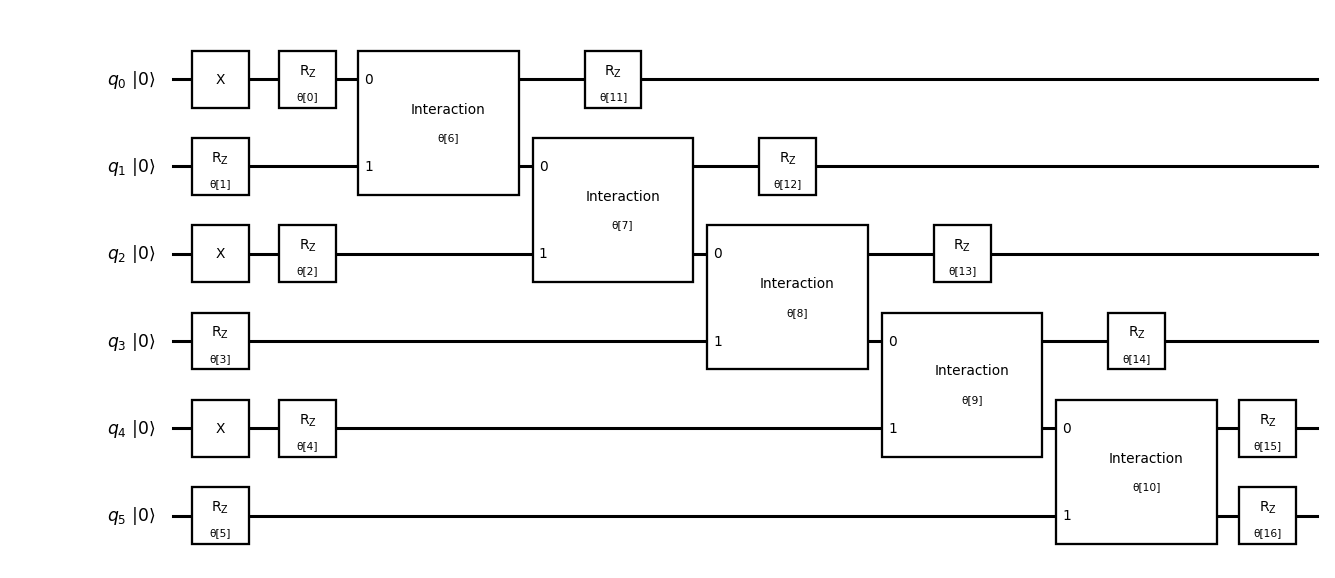

In [4]:
ansatz = "ExcitationPreserving"
fig = plot_ansatz_circuit(config, L_circuit_plots, reps_circuit_plots, ansatz)
# Save circuit
if SAVE_SIMULATED_DATA:
    file_name = f"00_01_Circuit_{ansatz}"
    save_data(fig, analysis_name, f"{file_name}.png", rootPath=plt_folder, dpi=300)
    save_data(fig, analysis_name, f"{file_name}.pdf", rootPath=plt_folder, dpi=300)
plt.show()

### 1.b HVA Simple


######################################################################
2026-05-08 01:10:26 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:10:26 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:10:26 INFO: Using ansatz HVA Simple with parameters: {'num_qubits': 6, 'entanglement': 'linear', 'reps': 1}


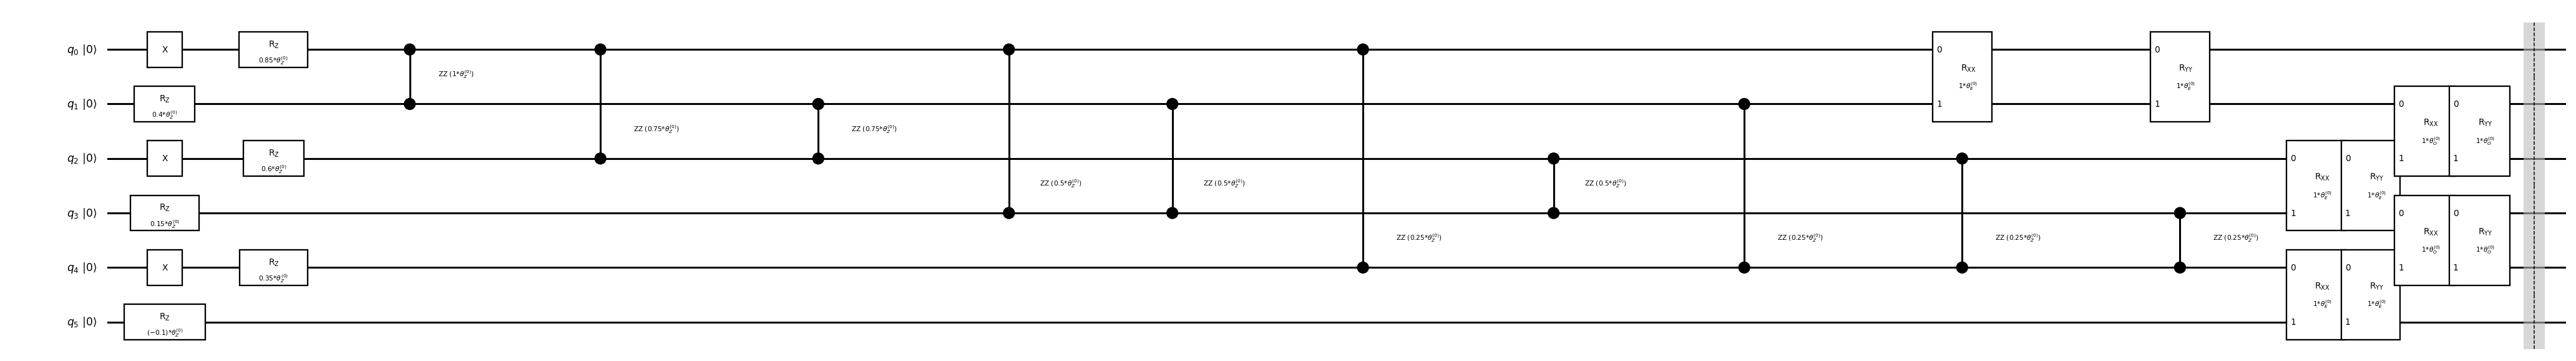

In [5]:
ansatz = "HVA Simple"
fig = plot_ansatz_circuit(config, L_circuit_plots, reps_circuit_plots, ansatz)
# Save circuit
if SAVE_SIMULATED_DATA:
    file_name = f"00_01_Circuit_{ansatz}"
    save_data(fig, analysis_name, f"{file_name}.png", rootPath=plt_folder, dpi=300)
    save_data(fig, analysis_name, f"{file_name}.pdf", rootPath=plt_folder, dpi=300)
plt.show()

### 1.c HVA


######################################################################
2026-05-08 01:10:34 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:10:34 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:10:34 INFO: Using ansatz HVA with parameters: {'num_qubits': 6, 'entanglement': 'linear', 'reps': 1}


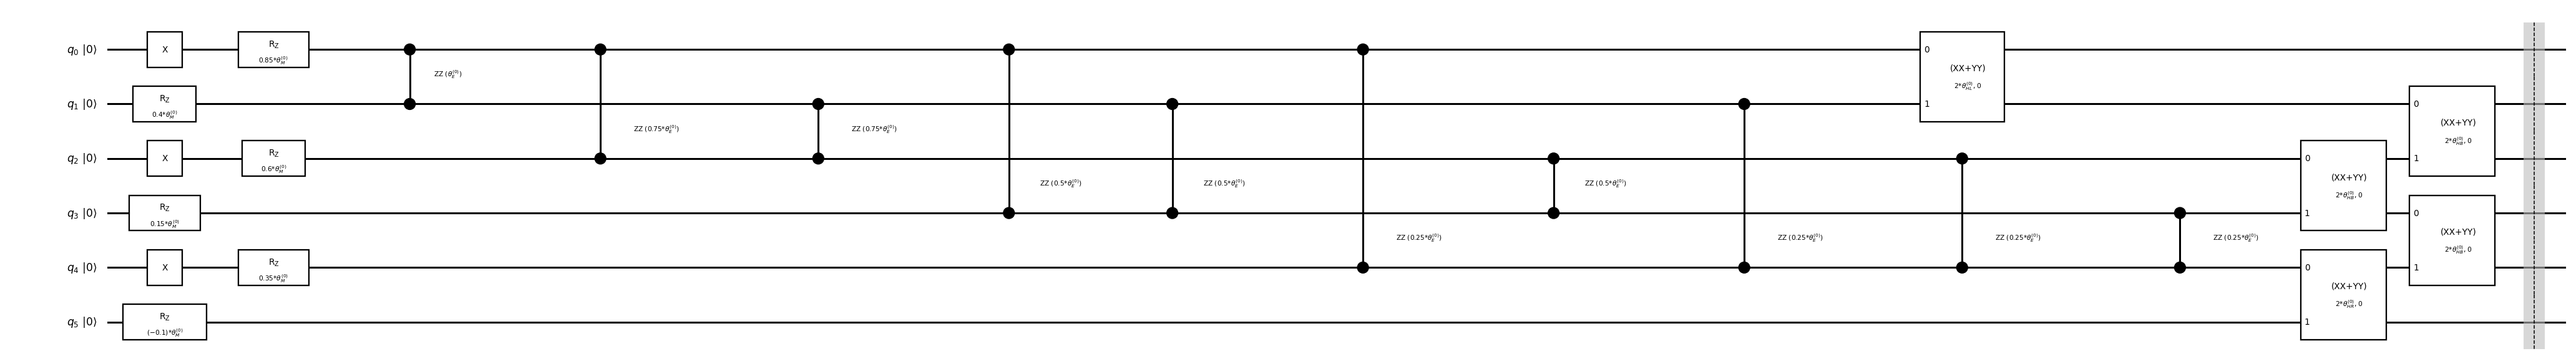

In [6]:
ansatz = "HVA"
fig = plot_ansatz_circuit(config, L_circuit_plots, reps_circuit_plots, ansatz)
# Save circuit
if SAVE_SIMULATED_DATA:
    file_name = f"00_01_Circuit_{ansatz}"
    save_data(fig, analysis_name, f"{file_name}.png", rootPath=plt_folder, dpi=300)
    save_data(fig, analysis_name, f"{file_name}.pdf", rootPath=plt_folder, dpi=300)
plt.show()

## 2. Validation metrics vs Ansatz Repetitions

For a fixed number of qubits, we perform a VQE on each ansatz, varying the number of repetitions. From the plots we infer that `reps=3` offers the best equilibrium, maximizing the precision without over-parametrization with acceptable execution times.

In [7]:
# Parameters for the study
reps_num = [1, 2, 3, 4]
qubits_num = 8  # Medium value
# Config set
ansatz_config = copy.deepcopy(config)
ansatz_config["QubitsNumber"] = qubits_num
ansatz_config["Hamiltonian"]["Parameters"]["L"] = qubits_num

In [8]:
# Run, getting the main metrics for each run
ansatzes_comparison = {}
for ansatz in ansatzes:
    ansatz_config["Ansatz"]["Type"] = ansatz
    ansatz_comparison = {}
    for reps in reps_num:
        analysis_name_reps = f"{analysis_name}_{reps}_Reps"
        reps_config = copy.deepcopy(ansatz_config)
        reps_config["Ansatz"]["Reps"] = reps
        comparisons = get_ansatz_comparison(
            reps_config, [qubits_num], analysis_name=analysis_name_reps
        )
        if reps != qubits_num:
            comparisons[reps] = comparisons[qubits_num]
            del comparisons[qubits_num]
        ansatz_comparison = {**ansatz_comparison, **comparisons}
    ansatzes_comparison[ansatz] = ansatz_comparison

2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 29.79 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 32.66 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 27.82 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 29.70 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 29.33 seconds.
2026-05-08 01:10:37 INFO: Overlap for 8 qubits: 0.9495973473784449
2026-05-08 01:10:37 INFO: Energy error for 8 qubits: 0.015317794705116562
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 39.88 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 35.09 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 45.51 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 43.46 seconds.
2026-05-08 01:10:37 INFO: Simulation for 8 qubits took 47.71 seconds.
2026-05-08 01:10:37 INFO: Overlap for 8 qubits: 0.9981365088599519
2026-05-08 01:10:37 INFO: Energy error for 8 qubits: 0.0007895753331840277
2026-05-08 01:10:

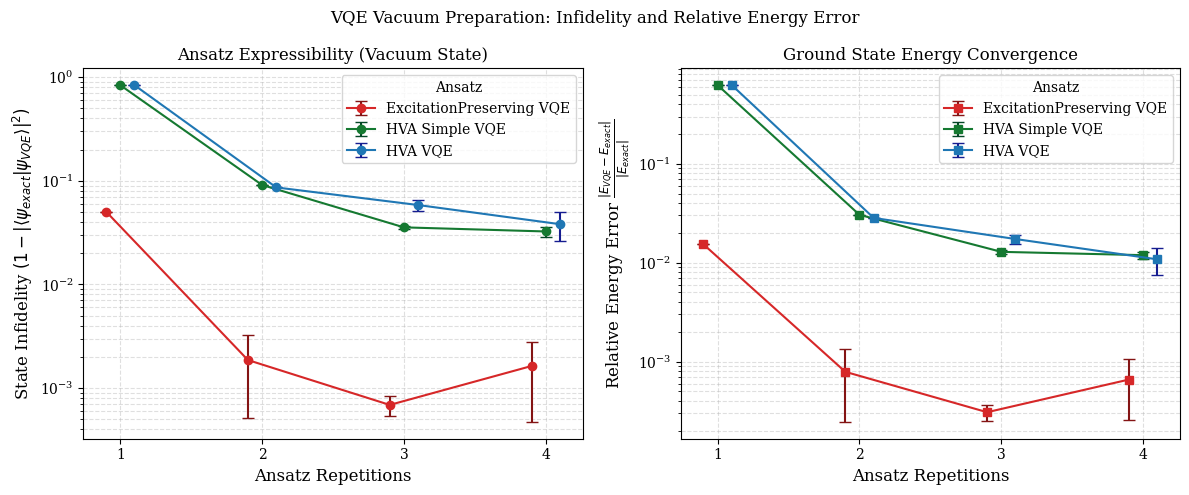

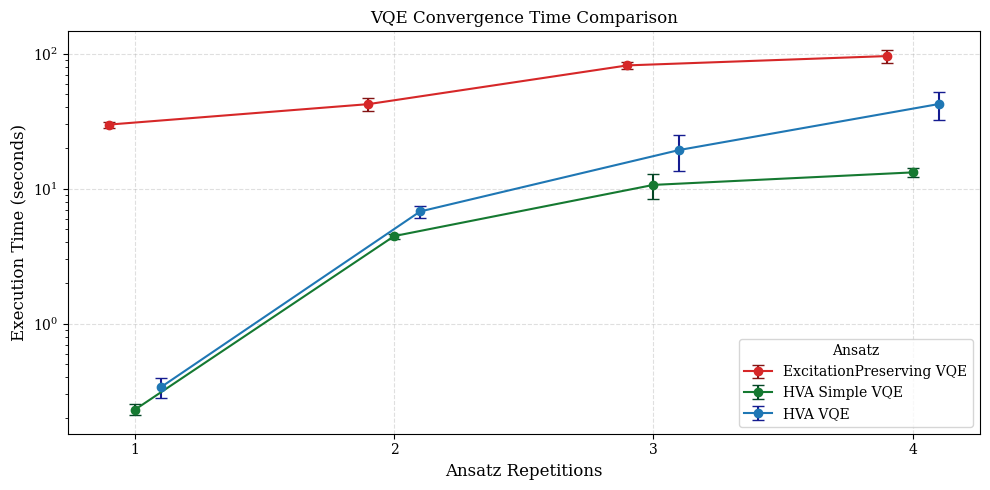

In [9]:
# Infidelity ($1 - \text{Overlap}$) in logarithmic scale on Y axis.
fig_err, axes = plot_validation_ansatzes(
    reps_num, ansatzes_comparison, x_label="Ansatz Repetitions"
)
# VQE Convergence Time
fig_dur, ax = plot_duration_ansatzes(
    reps_num, ansatzes_comparison, x_label="Ansatz Repetitions"
)
if SAVE_SIMULATED_DATA:
    # Save plot
    file_name = "00_02_Overlap_Vs_Reps"
    save_data(
        fig_err, analysis_name, f"{file_name}_Errors.png", rootPath=plt_folder, dpi=300
    )
    save_data(
        fig_err, analysis_name, f"{file_name}_Errors.pdf", rootPath=plt_folder, dpi=300
    )
    save_data(
        fig_dur,
        analysis_name,
        f"{file_name}_Duration.png",
        rootPath=plt_folder,
        dpi=300,
    )
    save_data(
        fig_dur,
        analysis_name,
        f"{file_name}_Duration.pdf",
        rootPath=plt_folder,
        dpi=300,
    )
    save_data(ansatz_comparison, analysis_name, f"{file_name}.pkl", rootPath=plt_folder)

plt.show()

## 3. Validation metrics vs Number of Qubits

After fixing `reps=3` as the circuit depth, we see how are the fidelities and the energy error with the exact state.

ExcitationPreserving keeps fidelities greater than $99\%$ for all the values studied, and errors in energy below $10^{-3}$. HVA ansatzes fail to capture the whole ground state, even though the errors in energy remain acceptable, fidelity decays below $95\%$. They converge faster to the ground state, but all the convergence times fall in the same magnitude order.

In [10]:
# Number of qubits to use
qubits_nums = [4, 6, 8, 10, 12, 14, 16]

In [11]:
# Get metrics for all numbers of qubits for each ansatz
ansatz_comparison = {}
for ansatz in ansatzes:
    ansatz_config = copy.deepcopy(config)
    ansatz_config["Ansatz"]["Type"] = ansatz
    comparisons = get_ansatz_comparison(
        ansatz_config,
        qubits_nums,
        runs=15,
        parallel_runs=5,
        analysis_name=analysis_name,
    )
    ansatz_comparison = {**ansatz_comparison, **{ansatz: comparisons}}

2026-05-08 01:10:44 INFO: Simulation for 4 qubits took 7.31 seconds.
2026-05-08 01:10:44 INFO: Simulation for 4 qubits took 8.72 seconds.
2026-05-08 01:10:44 INFO: Simulation for 4 qubits took 9.30 seconds.
2026-05-08 01:10:44 INFO: Simulation for 4 qubits took 8.55 seconds.
2026-05-08 01:10:44 INFO: Simulation for 4 qubits took 6.36 seconds.
2026-05-08 01:10:44 INFO: Overlap for 4 qubits: 0.9999839655726734
2026-05-08 01:10:44 INFO: Energy error for 4 qubits: 2.891589984892966e-05
2026-05-08 01:10:44 INFO: Simulation for 6 qubits took 29.83 seconds.
2026-05-08 01:10:44 INFO: Simulation for 6 qubits took 35.74 seconds.
2026-05-08 01:10:44 INFO: Simulation for 6 qubits took 28.36 seconds.
2026-05-08 01:10:44 INFO: Simulation for 6 qubits took 34.11 seconds.
2026-05-08 01:10:44 INFO: Simulation for 6 qubits took 33.75 seconds.
2026-05-08 01:10:44 INFO: Overlap for 6 qubits: 0.9997593644360254
2026-05-08 01:10:44 INFO: Energy error for 6 qubits: 0.00018167143069794771
2026-05-08 01:10:44 

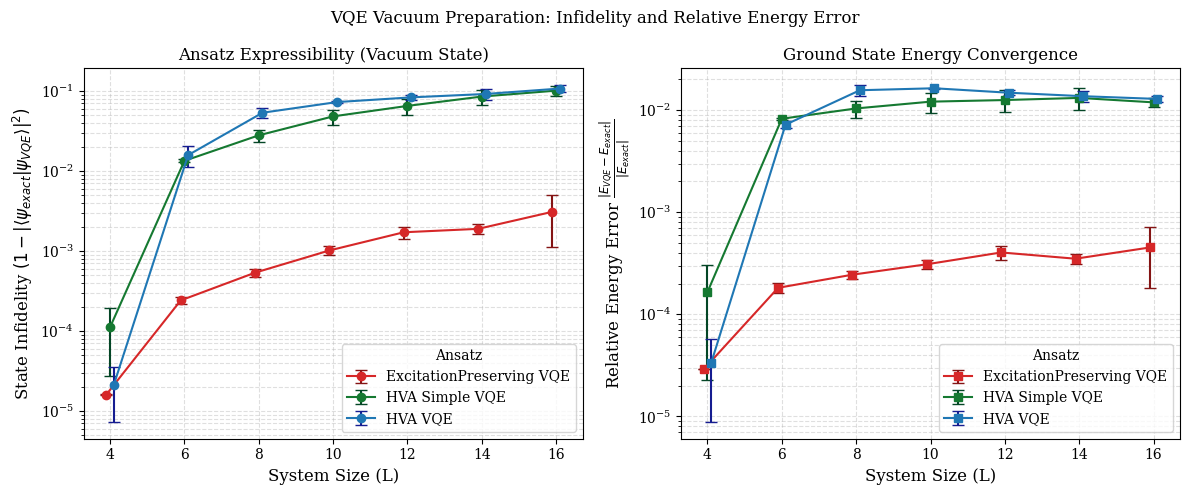

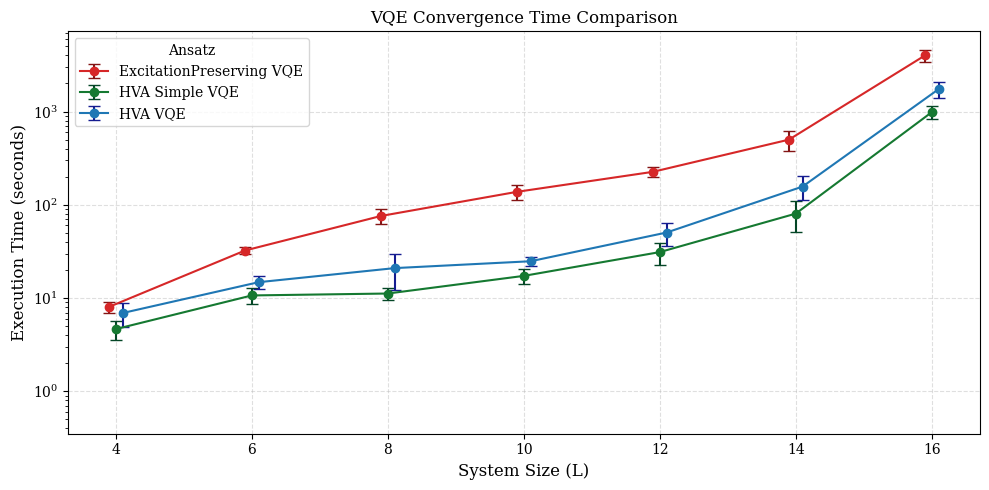

In [12]:
# Infidelity ($1 - \text{Overlap}$) in logarithmic scale on Y axis.
fig_err, axes = plot_validation_ansatzes(qubits_nums, ansatz_comparison)
# VQE Convergence Time
fig_dur, ax = plot_duration_ansatzes(qubits_nums, ansatz_comparison)

# Save plot
if SAVE_SIMULATED_DATA:
    file_name = "00_03_Overlap_Vs_Qubits"
    save_data(
        fig_err, analysis_name, f"{file_name}_Errors.png", rootPath=plt_folder, dpi=300
    )
    save_data(
        fig_err, analysis_name, f"{file_name}_Errors.pdf", rootPath=plt_folder, dpi=300
    )
    save_data(
        fig_dur,
        analysis_name,
        f"{file_name}_Duration.png",
        rootPath=plt_folder,
        dpi=300,
    )
    save_data(
        fig_dur,
        analysis_name,
        f"{file_name}_Duration.pdf",
        rootPath=plt_folder,
        dpi=300,
    )
    save_data(ansatz_comparison, analysis_name, f"{file_name}.pkl", rootPath=plt_folder)
plt.show()

## 4. Computational Resources

We check the computational resources needed to implement each one of the circuits on NISQ hardware, and how it scales with the number of qubits, looking the number of CNOTs needed and the depth in the circuit transpile to native IBM gates.

We find that ExcitationPreserving shows the best behaviour, using the least resources of the 3, with the number of CNOTs and the depth scaling linearly with L. For HVA and HVA simple, depths are bigger (although they remain linear) and the number CNOTs grows polinomially.

In [13]:
# Native IBM Quantum Gates (Eagle/Heron)
ibm_basis_gates = ["cx", "rz", "sx", "x"]

L_vals = [4, 6, 8, 10]

In [14]:
depths, cnots = {}, {}

for ansatz in ansatzes:
    ansatz_config = copy.deepcopy(config)
    ansatz_config["Ansatz"]["Type"] = ansatz

    depths[ansatz] = {}
    cnots[ansatz] = {}
    for L in L_vals:
        ansatz_config["QubitsNumber"] = L
        ansatz_config["Hamiltonian"]["Parameters"]["L"] = L
        sim = SchwingerSimulation(copy.deepcopy(ansatz_config))
        sim.hamiltonian_prep = sim.get_hamiltonian()
        ansatz_circuit = sim.get_ansatz()

        # Transpile to level 2 (medium optimization, Qiskit standard)
        transpiled_circ = transpile(
            ansatz_circuit, basis_gates=ibm_basis_gates, optimization_level=2
        )

        # Extract metrics
        depths[ansatz][L] = transpiled_circ.depth()
        cnots[ansatz][L] = transpiled_circ.count_ops().get("cx", 0)


######################################################################
2026-05-08 01:11:41 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:11:41 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:11:41 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 4, 'entanglement': 'linear', 'reps': 3}

######################################################################
2026-05-08 01:11:41 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:11:41 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:11:41 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 6, 'entanglement': 'linear', 'reps': 3}

######################################################################
2026-05-08 01:11:41 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:11:41 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:11:41 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 8, 'e

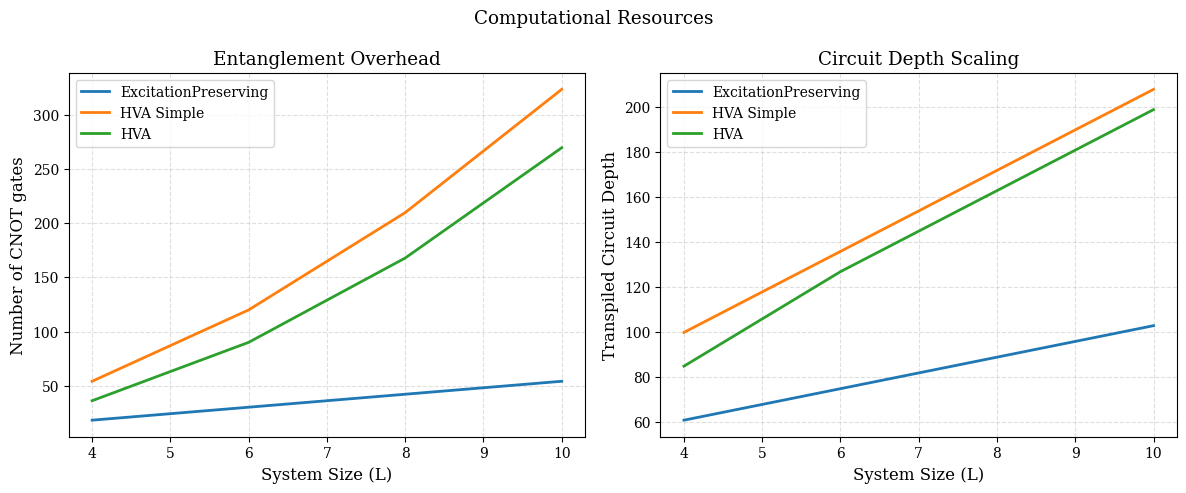

In [15]:
# Plot resources (CNOTs and depth)
fig_cost, axes_cost = plot_computational_resources(ansatzes, L_vals, depths, cnots)
# Save plot
if SAVE_SIMULATED_DATA:
    file_name = "00_04_ComputationalResources"
    save_data(fig_cost, analysis_name, f"{file_name}.png", rootPath=plt_folder, dpi=300)
    save_data(fig_cost, analysis_name, f"{file_name}.pdf", rootPath=plt_folder, dpi=300)
    save_data(
        {"depths": depths, "cnots": cnots},
        analysis_name,
        f"{file_name}.pkl",
        rootPath=plt_folder,
    )
plt.show()

## 5. Barren Plateaus

We see the scalability of each circuit by looking at the gradient variance. If it decays exponentially, the ansatz is likely to suffer barren plateus (regions with plain gradient, making it difficult and computationally expensive for VQE to find the ground state).

Both HVA show good behaviour, with no signs of decay. However, we see that Excitation Preserving shows some descents, which make it lekely to suffer this effect.

In [16]:
# Numbers of qubits
L_vals = [4, 6, 8, 10, 12]

In [17]:
# Get gradient variance for each ansatz and number of qubits
var_grads = {}

for ansatz in ansatzes:
    ansatz_config = copy.deepcopy(config)
    ansatz_config["Ansatz"]["Type"] = ansatz

    var_grads[ansatz] = {}
    for L in L_vals:
        ansatz_config["QubitsNumber"] = L
        ansatz_config["Hamiltonian"]["Parameters"]["L"] = L
        sim = SchwingerSimulation(copy.deepcopy(ansatz_config))
        sim.hamiltonian_prep = sim.get_hamiltonian()
        ansatz_circuit = sim.get_ansatz()

        # Sparse hamiltonian
        H_sparse = sim.hamiltonian_prep.to_matrix(sparse=True)

        # Calculate variances with 100 random samples
        ansatz_var = calculate_global_gradient_variance(
            ansatz_circuit, H_sparse, num_samples=100
        )

        # Extract metrics
        var_grads[ansatz][L] = ansatz_var


######################################################################
2026-05-08 01:11:43 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:11:43 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:11:43 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 4, 'entanglement': 'linear', 'reps': 3}

######################################################################
2026-05-08 01:12:43 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:12:43 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:12:43 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 6, 'entanglement': 'linear', 'reps': 3}

######################################################################
2026-05-08 01:15:14 INFO: Initializing SchwingerSimulation class.
2026-05-08 01:15:14 INFO: Using StatevectorEstimator (Ideal V2 Primitive).
2026-05-08 01:15:14 INFO: Using ansatz ExcitationPreserving with parameters: {'num_qubits': 8, 'e

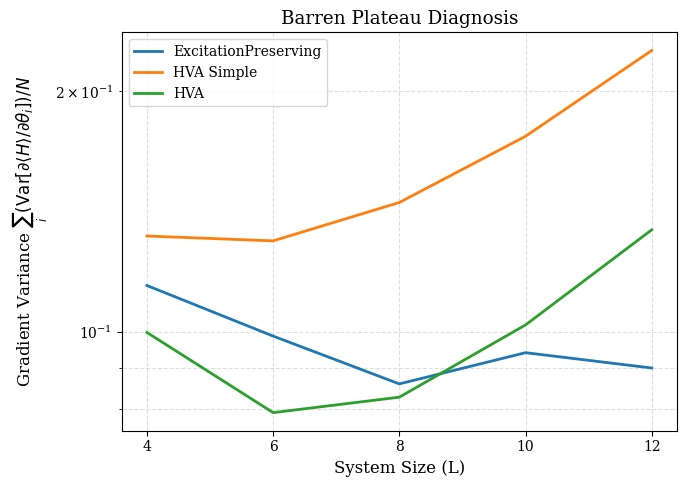

In [18]:
# Plot variance decay
fig_bp, ax = plot_variance_decay(ansatzes, L_vals, var_grads)
# Save plot
if SAVE_SIMULATED_DATA:
    file_name = "00_05_BarrenPlateaus"
    save_data(fig_cost, analysis_name, f"{file_name}.png", rootPath=plt_folder, dpi=300)
    save_data(fig_cost, analysis_name, f"{file_name}.pdf", rootPath=plt_folder, dpi=300)
    save_data(var_grads, analysis_name, f"{file_name}.pkl", rootPath=plt_folder)
plt.show()